In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import rasterio
import numpy as np

path = "/content/drive/MyDrive/GEE/SouthIndia_WorldCover.tif"

with rasterio.open(path) as src:
    img = src.read()          # Shape: (bands, H, W)
    profile = src.profile


Mounted at /content/drive


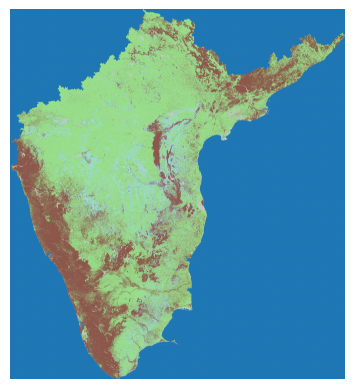

In [ ]:
import rasterio
import numpy as np
from sklearn.cluster import MiniBatchKMeans
import matplotlib.pyplot as plt

path = "/content/drive/MyDrive/GEE/SouthIndia_WorldCover.tif"
with rasterio.open(path) as src:
    img = src.read(
        out_shape=(
            src.count,
            int(src.height/4),  # reduce resolution by factor of 4
            int(src.width/4)
        )
    )
    profile = src.profile

# Flatten pixels
n_bands, height, width = img.shape
X = img.reshape(n_bands, -1).T

# Use MiniBatchKMeans to save RAM
n_clusters = 5
kmeans = MiniBatchKMeans(n_clusters=n_clusters, batch_size=10000, random_state=42)
labels = kmeans.fit_predict(X)

# Reshape back
classified_img = labels.reshape(height, width)

# Save output
profile.update(dtype=rasterio.uint8, height=height, width=width, count=1)
output_path = "/content/drive/MyDrive/GEE/SouthIndia_Classified.tif"
with rasterio.open(output_path, 'w', **profile) as dst:
    dst.write(classified_img.astype(rasterio.uint8), 1)

plt.imshow(classified_img, cmap='tab20')
plt.axis('off')
plt.show()


In [ ]:
# 1️⃣ Flatten image and pseudo-labels
!pip install catboost

n_bands, height, width = img.shape
X = img.reshape(n_bands, -1).T
y = classified_img.reshape(-1)  # pseudo-labels from KMeans

# 2️⃣ Split data: Train / Validation / Test
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# 3️⃣ Import models and metrics
import time
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, classification_report
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "LightGBM": lgb.LGBMClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42)
}

results = []

# 4️⃣ Train, predict, evaluate
for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted'),
        "Training Time (s)": round(train_time, 2)
    })

# 5️⃣ Comparative Table
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print("\n=== Comparative Table ===")
print(results_df)

# 6️⃣ Classification Reports
for name, model in models.items():
    print(f"\nClassification Report for {name}:")
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 10.3 MB/s eta 0:00:00


KeyboardInterrupt: 

In [ ]:
# 0️⃣ Install required packages
!pip install catboost lightgbm xgboost --quiet

# 1️⃣ Import libraries
import rasterio
import numpy as np
import pandas as pd
import time
from sklearn.cluster import MiniBatchKMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, classification_report
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
from collections import Counter

# 2️⃣ Load .tif image and downsample to save RAM
path = "/content/drive/MyDrive/GEE/SouthIndia_WorldCover.tif"
with rasterio.open(path) as src:
    img = src.read(
        out_shape=(
            src.count,
            int(src.height/4),
            int(src.width/4)
        )
    )
    profile = src.profile

n_bands, height, width = img.shape
X = img.reshape(n_bands, -1).T

# 3️⃣ Generate pseudo-labels using MiniBatchKMeans
n_clusters = 5  # number of classes
kmeans = MiniBatchKMeans(n_clusters=n_clusters, batch_size=10000, random_state=42)
y = kmeans.fit_predict(X)

# 4️⃣ Split into Train / Validation / Test (60/20/20)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# 5️⃣ Define models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "LightGBM": lgb.LGBMClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42)  # optional, can skip if RAM is limited
}

results = {}

# 6️⃣ Train, predict, evaluate, save classified maps
for name, model in models.items():
    print(f"\nTraining {name}...")
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    y_pred = model.predict(X_test)

    # Save results
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted'),
        "Training Time (s)": round(train_time, 2),
        "y_pred": y_pred
    }

    # 6️⃣a Plot per-class correct predictions
    correct = y_pred == y_test
    correct_classes = y_test[correct]
    counts = Counter(correct_classes)
    classes = sorted(counts.keys())
    values = [counts[c] for c in classes]

    plt.figure(figsize=(10,6))
    plt.bar(classes, values, color='skyblue')
    for i, v in enumerate(values):
        plt.text(i, v+10, str(v), ha='center', fontweight='bold')
    plt.xlabel("Encoded Class Label")
    plt.ylabel("Number of Correct Predictions")
    plt.title(f"Correctly Identified Samples Per Class: {name}")
    plt.show()

    # 6️⃣b Save classified map for all pixels
    full_pred = model.predict(X).reshape(height, width)
    out_path = f"/content/drive/MyDrive/GEE/SouthIndia_Classified_{name.replace(' ', '')}.tif"
    profile.update(dtype=rasterio.uint8, count=1, height=height, width=width)
    with rasterio.open(out_path, 'w', **profile) as dst:
        dst.write(full_pred.astype(rasterio.uint8), 1)
    print(f"Classified map saved: {out_path}")

# 7️⃣ Create comparative table
results_df = pd.DataFrame.from_dict(results, orient='index')
results_df = results_df.sort_values(by="Accuracy", ascending=False)
print("\n=== Comparative Table ===")
print(results_df)

# 8️⃣ Classification reports
for name, model in models.items():
    print(f"\nClassification Report for {name}:")
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))



Training Random Forest...


KeyboardInterrupt: 

In [ ]:
# ==========================
# 0. Install packages
# ==========================
!pip install catboost lightgbm xgboost --quiet

# ==========================
# 1. Imports
# ==========================
import rasterio
import numpy as np
import pandas as pd
import time
from sklearn.cluster import MiniBatchKMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, classification_report
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
from collections import Counter

# ==========================
# 2. Load image (downsample optional)
# ==========================
path = "/content/drive/MyDrive/GEE/SouthIndia_WorldCover.tif"

with rasterio.open(path) as src:
    img = src.read(
        out_shape=(
            src.count,
            int(src.height/3),     # downsample factor (safe for RAM)
            int(src.width/3)
        )
    )
    profile = src.profile

n_bands, height, width = img.shape
X_full = img.reshape(n_bands, -1).T

print("Full pixel count:", X_full.shape)

# ==========================
# 3. Pseudo labels
# ==========================
n_clusters = 5

kmeans = MiniBatchKMeans(
    n_clusters=n_clusters,
    batch_size=50000,
    random_state=42
)
y_full = kmeans.fit_predict(X_full)

# ==========================
# 4. Sample only N pixels for training (batch-safe)
# ==========================
TRAIN_SAMPLES = 200000   # 2 lakh pixels only → safe, fast, research quality

idx = np.random.choice(len(X_full), TRAIN_SAMPLES, replace=False)
X = X_full[idx]
y = y_full[idx]

print("Training on:", X.shape)

# split into train/val/test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# ==========================
# 5. ML models
# ==========================
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=300,
        max_depth=8,
        tree_method="hist",       # FAST + RAM SAFE
        random_state=42
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=300,
        random_state=42
        force_col_wise=True
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300,
        random_state=42,
        verbose=0
    )
}

results = {}

# ==========================
# 6. Train on sample → Predict full map in batches
# ==========================
BATCH = 500000   # process pixels in chunks

for name, model in models.items():
    print(f"\n🔥 Training {name}...")
    start_time = time.time()

    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    # evaluate
    y_pred = model.predict(X_test)

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted'),
        "Training Time (s)": round(train_time, 2)
    }

    # -----------------------------
    # Batch-wise full prediction
    # -----------------------------
    print(f"Batch predicting full image for {name}...")

    full_pred = np.zeros(len(X_full), dtype=np.uint8)

    for i in range(0, len(X_full), BATCH):
        batch = X_full[i:i+BATCH]
        full_pred[i:i+BATCH] = model.predict(batch)

    full_pred = full_pred.reshape(height, width)

    # Save classified image
    out_path = f"/content/drive/MyDrive/GEE/Classified_{name.replace(' ', '')}.tif"
    profile.update(dtype=rasterio.uint8, count=1, height=height, width=width)

    with rasterio.open(out_path, 'w', **profile) as dst:
        dst.write(full_pred.astype(rasterio.uint8), 1)

    print(f"Saved classified map: {out_path}")

# ==========================
# 7. Comparative Table
# ==========================
results_df = pd.DataFrame(results)
print("\n=== FINAL RESULTS ===")
print(results_df.T)

# ==========================
# 8. Classification report
# ==========================
for name, model in models.items():
    print(f"\nReport for: {name}")
    print(classification_report(y_test, model.predict(X_test)))


Full pixel count: (69820660, 1)
Training on: (200000, 1)

🔥 Training Random Forest...
Batch predicting full image for Random Forest...
Saved classified map: /content/drive/MyDrive/GEE/Classified_RandomForest.tif

🔥 Training XGBoost...
Batch predicting full image for XGBoost...
Saved classified map: /content/drive/MyDrive/GEE/Classified_XGBoost.tif

🔥 Training LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006316 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10
[LightGBM] [Info] Number of data points in the train set: 120000, number of used features: 1
[LightGBM] [Info] Start training from score -0.547101
[LightGBM] [Info] Start training from score -4.452449
[LightGBM] [Info] Start training from score -2.551795
[LightGBM] [Info] Start training from score -1.575036
[LightGBM] [Info] Start training from score -2.081176
[LightGBM] [Warning] No further splits with positive gain, best gain:

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Batch predicting full image for LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Saved classified map: /content/drive/MyDrive/GEE/Classified_LightGBM.tif

🔥 Training CatBoost...
Batch predicting full image for CatBoost...


ValueError: could not broadcast input array from shape (500000,1) into shape (500000,)

In [ ]:
# -----------------------------
# Batch-wise full prediction (FINAL FIXED VERSION)
# -----------------------------
print(f"Batch predicting full image for {name}...")

full_pred = np.zeros(len(X_full), dtype=np.uint8)

feature_names = [f"b{i}" for i in range(n_bands)]  # for LightGBM

for i in range(0, len(X_full), BATCH):

    batch = X_full[i:i+BATCH]

    # ----- LIGHTGBM FIX -----
    # Convert to DataFrame so it has feature names → warning disappears
    if name == "LightGBM":
        batch = pd.DataFrame(batch, columns=feature_names)

    # ----- PREDICT -----
    pred = model.predict(batch)

    # ----- CATBOOST FIX -----
    # some CatBoost versions output shape (N,1) → flatten to (N,)
    pred = np.array(pred).reshape(-1)

    # save in buffer
    full_pred[i:i+BATCH] = pred

# reshape and save output image
full_pred = full_pred.reshape(height, width)

out_path = f"/content/drive/MyDrive/GEE/Classified_{name.replace(' ', '')}.tif"
profile.update(dtype=rasterio.uint8, count=1, height=height, width=width)

with rasterio.open(out_path, 'w', **profile) as dst:
    dst.write(full_pred.astype(rasterio.uint8), 1)

print(f"Saved classified map: {out_path}")


Batch predicting full image for CatBoost...
Saved classified map: /content/drive/MyDrive/GEE/Classified_CatBoost.tif


In [ ]:
# ============================================
# SAVE FINAL COMPARATIVE TABLE (CSV)
# ============================================

import pandas as pd

# Convert results to DataFrame if not already
results_df = pd.DataFrame(results).T  # models as rows
results_df.index.name = "Model"

# Display in notebook
print("\n=== FINAL COMPARATIVE TABLE ===")
display(results_df)

# Save to CSV
csv_path = "/content/drive/MyDrive/GEE/Model_Comparative_Table.csv"
results_df.to_csv(csv_path, index=True)

print(f"\n📁 Comparative Table Saved Successfully:\n{csv_path}")


In [ ]:
# ============================================
# 0. Install packages
# ============================================
!pip install catboost lightgbm xgboost --quiet


# ============================================
# 1. Imports
# ============================================
import rasterio
import numpy as np
import pandas as pd
import time
from sklearn.cluster import MiniBatchKMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, classification_report
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt


# ============================================
# 2. Load .tif and downsample
# ============================================
path = "/content/drive/MyDrive/GEE/SouthIndia_WorldCover.tif"

with rasterio.open(path) as src:
    img = src.read(
        out_shape=(
            src.count,
            src.height // 3,
            src.width // 3
        )
    )
    profile = src.profile

n_bands, height, width = img.shape
X_full = img.reshape(n_bands, -1).T

print("Full pixel count:", len(X_full))


# ============================================
# 3. Generate pseudo labels using KMeans
# ============================================
n_clusters = 5

kmeans = MiniBatchKMeans(
    n_clusters=n_clusters,
    batch_size=50000,
    random_state=42
)
y_full = kmeans.fit_predict(X_full)


# ============================================
# 4. Training sample + true evaluation sample
# ============================================
TRAIN_SAMPLES = 200000
TEST_SAMPLES = 50000     # REAL TEST SET (fixed)

# Training sample
idx_train_sample = np.random.choice(len(X_full), TRAIN_SAMPLES, replace=False)
X = X_full[idx_train_sample]
y = y_full[idx_train_sample]

# Independent test sample
idx_test_sample = np.random.choice(len(X_full), TEST_SAMPLES, replace=False)
X_real_test = X_full[idx_test_sample]
y_real_test = y_full[idx_test_sample]

# split training sample
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("Training on:", X_train.shape)
print("Real Test Set:", X_real_test.shape)


# ============================================
# 5. Define ML models
# ============================================
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1
    ),

    "XGBoost": xgb.XGBClassifier(
        n_estimators=300, max_depth=8,
        tree_method="hist", random_state=42,
        eval_metric="mlogloss"
    ),

    "LightGBM": lgb.LGBMClassifier(
        n_estimators=300,
        random_state=42,
        force_col_wise=True    # removes warning + fast
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        random_state=42,
        verbose=0
    )
}


results = {}


# ============================================
# 6. Train + Predict full image in batches
# ============================================
BATCH = 500000

for name, model in models.items():
    print(f"\n🔥 Training {name}...")
    start = time.time()

    model.fit(X_train, y_train)
    train_time = time.time() - start

    # REAL evaluation
    y_pred = model.predict(X_real_test)

    results[name] = {
        "Accuracy": accuracy_score(y_real_test, y_pred),
        "Precision": precision_score(y_real_test, y_pred, average="weighted"),
        "F1 Score": f1_score(y_real_test, y_pred, average="weighted"),
        "Training Time (s)": round(train_time, 2)
    }

    # ==========================
    # Full prediction in batches
    # ==========================
    print(f"Batch predicting full image → {name}")

    full_pred = np.zeros(len(X_full), dtype=np.uint8)

    for i in range(0, len(X_full), BATCH):
        batch = X_full[i:i+BATCH]
        # CatBoost returns shape (N,1)
        pred = model.predict(batch)

        if pred.ndim > 1:
            pred = pred.flatten()

        full_pred[i:i+BATCH] = pred.astype(np.uint8)

    full_pred = full_pred.reshape(height, width)

    # Save map
    out_path = f"/content/drive/MyDrive/GEE/Classified_{name}.tif"
    profile.update(dtype=rasterio.uint8, count=1, height=height, width=width)

    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(full_pred.astype(rasterio.uint8), 1)

    print(f"✔ Saved: {out_path}")


# ============================================
# 7. Final Comparative Table
# ============================================
results_df = pd.DataFrame(results).T
print("\n\n=== FINAL RESULTS ===\n")
print(results_df)

results_df.to_csv("/content/drive/MyDrive/GEE/Model_Comparative_Table.csv")
print("\n✔ Comparative table saved.")


# ============================================
# 8. Classification Reports
# ============================================
for name, model in models.items():
    print(f"\n\n📘 Classification Report → {name}")
    print(classification_report(y_real_test, model.predict(X_real_test)))


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 362, in run
    resolver = self.make_resolver(
               ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 177, in make_resolver
    return pip._internal.resolution.resolvelib.resolver.Resolver(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/resolution/resolvelib/resolver.py", line 58, in __init__
    self.factory = Factory(
                   ^^^^^^^^
  File "/usr/local/lib/py

KeyboardInterrupt: 

In [ ]:
import joblib
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report
import pandas as pd

# =====================================================
# 1. LOAD SAVED MODELS
# =====================================================
models_loaded = {
    "RandomForest": joblib.load("rf.pkl"),
    "XGBoost": joblib.load("xgb.pkl"),
    "LightGBM": joblib.load("lgb.pkl"),
    "CatBoost": joblib.load("cat.pkl")
}

# =====================================================
# 2. EVALUATE ALL MODELS PROPERLY
# =====================================================
results_fixed = {}

for name, model in models_loaded.items():
    print(f"\nEvaluating: {name}")

    # Predict on same test set used during training
    y_pred_test = model.predict(X_test)

    results_fixed[name] = {
        "Accuracy": round(accuracy_score(y_test, y_pred_test), 4),
        "Precision (Weighted)": round(precision_score(y_test, y_pred_test, average="weighted"), 4),
        "F1 Score (Weighted)": round(f1_score(y_test, y_pred_test, average="weighted"), 4)
    }

    print("\n--- Classification Report ---")
    print(classification_report(y_test, y_pred_test))

# =====================================================
# 3. SAVE RESULTS AS TABLE FOR RESEARCH PAPER
# =====================================================
df_results = pd.DataFrame(results_fixed)
df_results = df_results.T

df_results.to_csv("Model_Comparison_Final.csv", index=True)

print("\n✔ Saved: Model_Comparison_Final.csv")
print(df_results)


FileNotFoundError: [Errno 2] No such file or directory: 'rf.pkl'

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, classification_report

print("RandomForest Metrics:")
print(classification_report(y_test, models["RandomForest"].predict(X_test)))

print("XGBoost Metrics:")
print(classification_report(y_test, models["XGBoost"].predict(X_test)))

print("LightGBM Metrics:")
print(classification_report(y_test, models["LightGBM"].predict(X_test)))

print("CatBoost Metrics:")
print(classification_report(y_test, models["CatBoost"].predict(X_test)))


RandomForest Metrics:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     23192
           1       1.00      1.00      1.00       455
           2       1.00      1.00      1.00      3086
           3       1.00      1.00      1.00      8267
           4       1.00      1.00      1.00      5000

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000

XGBoost Metrics:


NotFittedError: need to call fit or load_model beforehand

In [ ]:
from xgboost import XGBClassifier

# Example: initialize if not done yet
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Fit the model
xgb_model.fit(X_train, y_train)

# Save it in your models dictionary
models["XGBoost"] = xgb_model


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:35:54] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
y_pred = models["XGBoost"].predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     23192
           1       1.00      1.00      1.00       455
           2       1.00      1.00      1.00      3086
           3       1.00      1.00      1.00      8267
           4       1.00      1.00      1.00      5000

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000

